In [14]:
from pydantic import BaseModel, Field
from typing import Literal

class Files(BaseModel):
    filename: str = Field(
        description="The name of the file that is to be planned"
    )
    purpose: str = Field(
        description="The purpose of the file that is to be planned"
    )

class AppPlanner(BaseModel):
    appname: str = Field(
        description="The name of the app to be designed",
    )
    description: str = Field(
        description="The description of the app to be designed",
    )
    tech_stack: list[str] = Field(
        description="The technical stack of the app to be designed like html, css, js, py, etc",
    )
    features: list[str] = Field(
        description="The features of the app to be designed",
    )
    files: list[Files] = Field(
        description="The list of files that are to be planned",
    )

class ArchitectureInstruction(BaseModel):
    filename: str = Field(
        description="The name of the file for which architecture instructions should be generated",
    )
    filepath: str = Field(
        description="The path of the file that should be generated",
    )
    instructions: list[str] = Field(
        description="The list of architecture instructions to be executed while coding",
    )

class AppArchitecture(BaseModel):
    architecture_files: list[ArchitectureInstruction] = Field(
        description="The architecture instruction of the app to be followed",
    )

class CodeFile(BaseModel):
    filename: str = Field(
        description="The name of the file to be coded",
    )
    filepath: str = Field(
        description="The path of the file that should be coded",
    )
    content: str = Field(
        description="The actual code lies inside this file",
    )
    extension: str = Field(
        description="The extension of the file to be coded, ex: py, html, js, css, etc",
    )

class AppCoder(BaseModel):
    code_files: list[CodeFile] = Field(
        description="The list of code files that need to be generated for this app",
    )

class AppState(dict):
    user_input: str
    plan: AppPlanner
    architecture: AppArchitecture
    code: AppCoder
    status: Literal["STARTED", "PLANNED", "ARCHITECTED", "CODING", "REVIEWING", "FIXING", "DONE"]
    coding_iteration: int


In [15]:
from langgraph import graph
from langgraph.graph import StateGraph, START, END

#Call memory here
builder = StateGraph(AppState)

def reviewer_router(p_state: AppState) -> str:
    if p_state["name"]=="DONE":
        return "END"
    else:
        return "coder_node"

def f1():
    print("hello")

builder.add_node("input_node", f1)
builder.add_node("planner_node", f1)
builder.add_node("architect_node", f1)
builder.add_node("coder_node", f1)
builder.add_node("reviewer_node", f1)
builder.add_node("fixer_node", f1)


builder.add_edge(START, "input_node")
builder.add_edge("input_node", "planner_node")
builder.add_edge("planner_node", "architect_node")
builder.add_edge("architect_node", "coder_node")
builder.add_edge("coder_node", "reviewer_node")
builder.add_conditional_edges(
    "reviewer_node",
    reviewer_router,{
        "END":END,
        "FIXING": "fixer_node"
    }
)

builder.add_edge("fixer_node", "coder_node")


# builder.add_edge("coder_node", END)

graph = builder.compile()



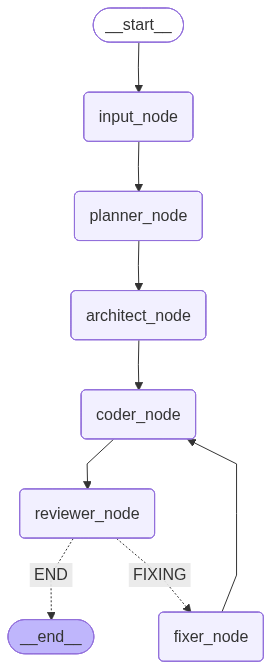

In [16]:
from IPython.display import Image, display

# Assumes 'graph' is your compiled StateGraph
display(Image(graph.get_graph().draw_mermaid_png()))